In [25]:
import sys
sys.path.append("..")   # to import from parent dir
import numpy as np
from IPython.display import HTML
import tonic
import matplotlib.pyplot as plt
import os.path as osp

from star8 import StarMovement
from utils.visualize_utils import animate_events
from utils.data_utils import *
from idn.loader.loader_dsec import HarrisRecursive

In [26]:
# Image/grid size
img_height = 256
img_width = 256
image_size = (img_height, img_width)

center = np.array([img_width // 2, img_height // 2])

total_frames = 2_000

num_points = 5
outer_radius = 40
inner_radius = 20

number_of_rotations = 2

# Trajectory of the local shape
added_height = 200
start_pos = np.array([center[0], 0])

In [27]:
star8 = StarMovement(
    total_frames=total_frames,
    image_size=image_size,
    face_color="black",
    num_points=num_points,
    outer_radius=outer_radius,
    inner_radius=inner_radius,
    number_of_rotations=number_of_rotations,
)

# Display animation

# anim = star8.create_animation(frame_step=20)
# HTML(anim.to_jshtml())

In [28]:
data_array = star8.generate_events()

transform = tonic.transforms.ToFrame(
    sensor_size=(star8.image_size[1], star8.image_size[0], 2),
    time_window=10,
    # event_count=500,
    overlap=0.5,
)
# anim = animate_events(data_array, transform, fig_size=(5,5))
# anim.save(filename="event_star8.gif", writer="pillow")
# HTML(anim.to_jshtml())

Generating Events: 100%|██████████| 2000/2000 [00:05<00:00, 361.84it/s]


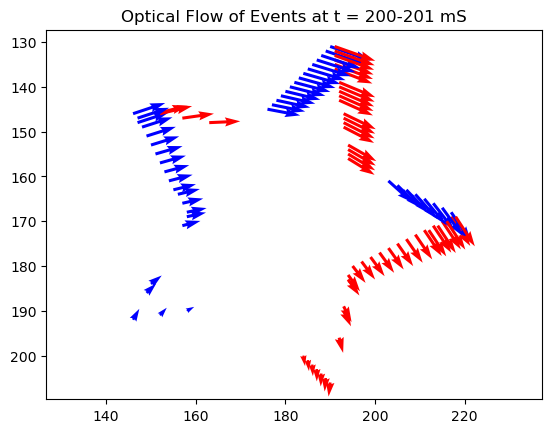

In [18]:
sample = data_array[(data_array['t'] >= 200) & (data_array['t'] <= 201)]
plt.quiver(sample['x'], sample['y'], 20* sample['v_x'], 20*sample['v_y'], 
           color=np.where(sample['p'], 'r', 'b'), angles='xy', scale_units='xy', scale=1)
plt.gca().invert_yaxis()
plt.axis('equal')
plt.title("Optical Flow of Events at t = 200-201 mS")
plt.savefig('optical_flow_at_200.png', dpi=300)
# plt.xlim(0, img_width)
# plt.ylim(0, img_height)
plt.show()

In [19]:
data_array = star8.generate_events()
data = numpy2pyg_event_convertor(data_array).clone()
data['v'] = torch.tensor([data_array['v_x'], data_array['v_y']]).T

Generating Events: 100%|██████████| 2000/2000 [00:05<00:00, 341.74it/s]
/tmp/ipykernel_5697/4242721653.py:3: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /opt/conda/conda-bld/pytorch_1678402411778/work/torch/csrc/utils/tensor_new.cpp:245.)
  data['v'] = torch.tensor([data_array['v_x'], data_array['v_y']]).T


In [20]:
filter_size = 5
tau = 1

In [21]:
harris_rec = HarrisRecursive(tau, filter_size, image_size)
harris_rec(data_array)
harris_eig1 = harris_rec.eig1
harris_eig2 = harris_rec.eig2
filter_values = harris_rec.filter_value_recursive

Using tau=1 and filter_size=5 for Harris Recursive


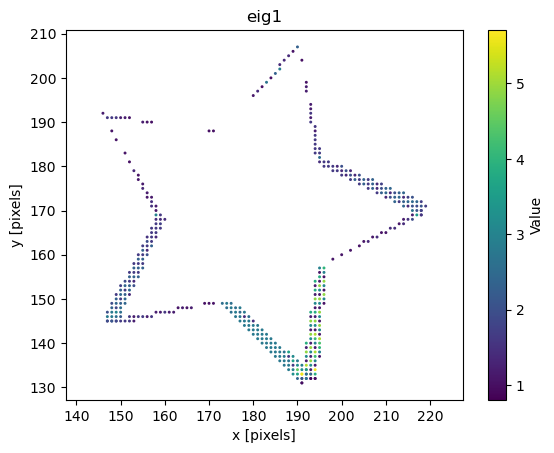

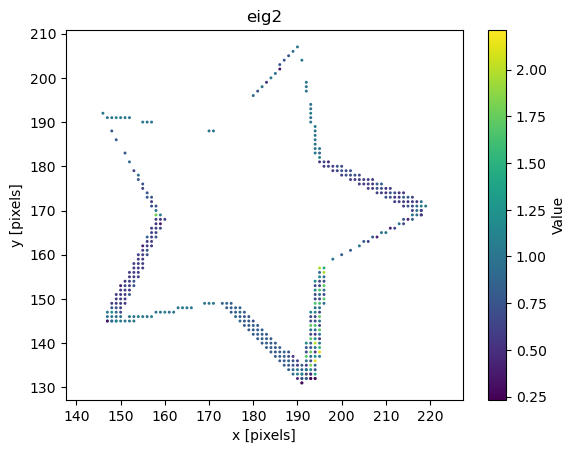

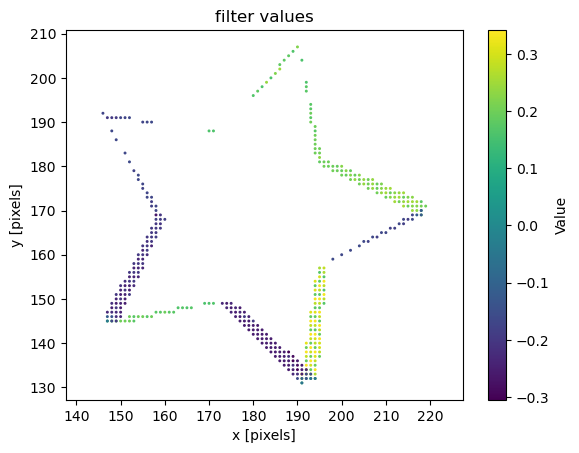

NameError: name 'v_mag' is not defined

In [22]:
idx = (data.pos[..., -1] > 200) & (data.pos[..., -1] < 210)
scatter = plt.scatter(data.pos[idx,0], data.pos[idx,1], c=harris_eig1[idx], cmap='viridis', marker='.', s=5)  # `c` maps color, `s` controls size
plt.colorbar(scatter, label='Value')
plt.xlabel('x [pixels]')
plt.ylabel('y [pixels]')
plt.title('eig1')
plt.axis('equal')
# plt.savefig(osp.join(saving_folder, f'filter_values.png'), dpi=300)
# Displaying the plot
plt.show()

scatter = plt.scatter(data.pos[idx,0], data.pos[idx,1], c=harris_eig2[idx], cmap='viridis', marker='.', s=5)  # `c` maps color, `s` controls size
plt.colorbar(scatter, label='Value')
plt.xlabel('x [pixels]')
plt.ylabel('y [pixels]')
plt.title('eig2')
plt.axis('equal')
# plt.savefig(osp.join(saving_folder, f'filter_values.png'), dpi=300)
# Displaying the plot
plt.show()

scatter = plt.scatter(data.pos[idx,0], data.pos[idx,1], c=filter_values[idx], cmap='viridis', marker='.', s=5)  # `c` maps color, `s` controls size
plt.colorbar(scatter, label='Value')
plt.xlabel('x [pixels]')
plt.ylabel('y [pixels]')
plt.title('filter values')
plt.axis('equal')
# plt.savefig(osp.join(saving_folder, f'filter_values.png'), dpi=300)
# Displaying the plot
plt.show()

scatter = plt.scatter(data.pos[idx,0], data.pos[idx,1], c=v_mag[idx], cmap='viridis', marker='.', s=5)  # `c` maps color, `s` controls size
plt.colorbar(scatter, label='Value')
plt.xlabel('x [pixels]')
plt.ylabel('y [pixels]')
plt.title('Magnitude of Velocity')
plt.axis('equal')
# plt.savefig(osp.join(saving_folder, f'magnitude_velocity.png'), dpi=300)
# Displaying the plot
plt.show()

sample = data_array[idx]
plt.quiver(sample['x'], sample['y'], 10* sample['v_x'], 10*sample['v_y'], 
           color=np.where(sample['p'], 'r', 'b'), angles='xy', scale_units='xy', scale=1)
plt.axis('equal')
plt.title("Optical Flow of Events")
# plt.savefig(osp.join(saving_folder, f'optical_flow_directions.png'), dpi=300)
plt.show()

In [23]:
import torch

pos = data.pos  # shape [num_nodes, num_features]

# Compute pairwise distances
dist = torch.cdist(pos, pos)  # [N, N]


In [50]:
k = 5  # number of neighbors (including self)
# Get the indices of k nearest neighbors for each node
knn_idx = dist.topk(k, largest=False).indices  # [N, k]
print(knn_idx[:10,:])

tensor([[   0, 2385,    2,    1, 2347],
        [   1,    4, 2386,    2,    0],
        [   2,    5,    1,    0,    4],
        [   3,    4, 2387,    7,    1],
        [   4,    1,    3,    8,    5],
        [   5,    4,    9,    2,    8],
        [   6, 2388,   11,    7,   10],
        [   7,    8,    3,   12,    6],
        [   8,   13,    7,    9,    4],
        [   9,   14,    5,    8,   13]])


In [51]:
def build_knn_features(X, knn_idx):
    """
    Expand input features using neighbors.
    Args:
        X: [N, F] feature matrix
        knn_idx: [N, k] indices of neighbors for each row
    Returns:
        knn_features: [N, k*F] expanded features
    """
    N, F = X.shape
    k = knn_idx.shape[1]
    
    # Gather neighbor features
    neighbors = X[knn_idx]  # shape [N, k, F]
    
    # Flatten neighbors for each row
    knn_features = neighbors.reshape(N, k * F)
    return knn_features

In [58]:
# Combine inputs and outputs
X = np.stack([data.pos[:,0], data.pos[:,1], harris_eig1, harris_eig2, filter_values], axis=1)  # shape (N, 4)
print("X shape:", X.shape)
Y = data.v
X_with_neighbors = build_knn_features(X, knn_idx)
print("X_with_neighbors shape:", X_with_neighbors.shape)

X shape: (105913, 5)
X_with_neighbors shape: (105913, 25)


In [66]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X_with_neighbors, Y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
Y_train = torch.tensor(Y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
Y_test = torch.tensor(Y_test, dtype=torch.float32)

/tmp/ipykernel_5697/2943781981.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_train = torch.tensor(Y_train, dtype=torch.float32)
/tmp/ipykernel_5697/2943781981.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_test = torch.tensor(Y_test, dtype=torch.float32)


In [69]:
X_with_neighbors.shape

(105913, 25)

In [67]:
X_train[:10,:]

tensor([[ 1.3900e+02,  9.2000e+01,  4.3245e+00,  1.3211e+00, -3.1153e-01,
          1.4000e+02,  9.2000e+01,  4.3929e+00,  1.3985e+00, -3.0893e-01,
          1.3800e+02,  9.2000e+01,  4.3131e+00,  1.3104e+00, -3.1205e-01,
          1.4100e+02,  9.2000e+01,  4.7517e+00,  1.6534e+00, -2.9864e-01,
          1.3700e+02,  9.2000e+01,  4.3108e+00,  1.3074e+00, -3.1218e-01],
        [ 1.5100e+02,  1.2400e+02,  1.0135e+01,  5.3058e-01,  5.7958e-01,
          1.5100e+02,  1.2500e+02,  1.0134e+01,  5.2527e-01,  5.7958e-01,
          1.5100e+02,  1.2300e+02,  1.0209e+01,  6.2176e-01,  5.7958e-01,
          1.5200e+02,  1.2400e+02,  1.0163e+01,  5.5858e-01,  5.7958e-01,
          1.5000e+02,  1.2400e+02,  1.0134e+01,  5.2527e-01,  5.7958e-01],
        [ 1.8400e+02,  7.3000e+01,  1.8133e+00,  8.5410e-01, -2.1719e-01,
          1.8300e+02,  7.3000e+01,  1.8139e+00,  8.5409e-01, -2.1718e-01,
          1.8500e+02,  7.3000e+01,  1.8261e+00,  8.1435e-01, -2.1719e-01,
          1.8600e+02,  7.2000e+01,  

In [75]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
        
    def forward(self, x):
        return self.net(x)

input_dim = X_train.size(1)
model = MLP(input_dim=input_dim, hidden_dim=64, output_dim=2)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 100
batch_size = 16

for epoch in range(epochs):
    model.train()
    permutation = torch.randperm(X_train.size(0))
    
    epoch_loss = 0
    for i in range(0, X_train.size(0), batch_size):
        idx = permutation[i:i+batch_size]
        batch_x = X_train[idx]
        batch_y = Y_train[idx]
        
        optimizer.zero_grad()
        preds = model(batch_x)
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * batch_x.size(0)
    
    epoch_loss /= X_train.size(0)
    
    # Validation
    model.eval()
    with torch.no_grad():
        preds_test = model(X_test)
        mse_test = criterion(preds_test, Y_test).item()
    
    print(f"Epoch {epoch+1:03d} | Train Loss: {epoch_loss:.4f} | Test MSE: {mse_test:.4f}")



Epoch 001 | Train Loss: 0.0732 | Test MSE: 0.0423
Epoch 002 | Train Loss: 0.0400 | Test MSE: 0.0391
Epoch 003 | Train Loss: 0.0356 | Test MSE: 0.0374
Epoch 004 | Train Loss: 0.0334 | Test MSE: 0.0336
Epoch 005 | Train Loss: 0.0322 | Test MSE: 0.0319
Epoch 006 | Train Loss: 0.0315 | Test MSE: 0.0308
Epoch 007 | Train Loss: 0.0307 | Test MSE: 0.0302
Epoch 008 | Train Loss: 0.0305 | Test MSE: 0.0317
Epoch 009 | Train Loss: 0.0303 | Test MSE: 0.0327
Epoch 010 | Train Loss: 0.0301 | Test MSE: 0.0290
Epoch 011 | Train Loss: 0.0297 | Test MSE: 0.0294
Epoch 012 | Train Loss: 0.0298 | Test MSE: 0.0281
Epoch 013 | Train Loss: 0.0295 | Test MSE: 0.0345
Epoch 014 | Train Loss: 0.0293 | Test MSE: 0.0281
Epoch 015 | Train Loss: 0.0288 | Test MSE: 0.0293
Epoch 016 | Train Loss: 0.0287 | Test MSE: 0.0308
Epoch 017 | Train Loss: 0.0284 | Test MSE: 0.0289
Epoch 018 | Train Loss: 0.0285 | Test MSE: 0.0273
Epoch 019 | Train Loss: 0.0283 | Test MSE: 0.0294
Epoch 020 | Train Loss: 0.0283 | Test MSE: 0.0280


In [46]:
mse = np.sum((preds_test.numpy() - Y_test.numpy())**2, axis=0)/(preds_test.shape[0])
print(mse)
print(mse.mean())

[0.02751565 0.02287619]
0.025195923


In [47]:
mse = np.sum((Y_test.numpy().mean(axis=0) - Y_test.numpy())**2, axis=0)/(Y_test.shape[0])
print(mse)
print(mse.mean())

[0.07427206 0.07350057]
0.07388632


In [49]:
mse = np.sum((preds_test.numpy().mean(axis=0) - preds_test.numpy())**2, axis=0)/(preds_test.shape[0])
print(mse)
print(mse.mean())

[0.04231481 0.05393229]
0.048123553
